# shallow_water_2d.ipynb

#### Robert Peal March 2026

- An implementation of the 2D linearised shallow water equations for use in the UIBK MSc extension programme on mountain regions, lecture 3b: Modelling
- The model evolves surface height anomaly η'(x,y,t) and depth-averaged winds (u,v) on an **Arakawa C-grid**
- A steady background inflow impinges on a Gaussian mountain, producing a clear quasi-steady lee wave pattern
- Students are encouraged to experiment with sections marked **(experiment here!)**

---

**Governing equations** (linearised about rest state H₀):

$$\frac{\partial \eta'}{\partial t} = -H_0 \left(\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}\right) + \text{nudge}$$

$$\frac{\partial u}{\partial t} = -g\frac{\partial (\eta' + h_b)}{\partial x} + fv - \nu u$$

$$\frac{\partial v}{\partial t} = -g\frac{\partial (\eta' + h_b)}{\partial y} - fu - \nu v$$

where η' is the surface height anomaly, h_b is the terrain, g is gravity, f is the Coriolis parameter, and ν is linear drag.

**Key improvement over a pulse initial condition:**
Rather than releasing a Gaussian pulse (which produces a messy superposition of reflections), we drive a **steady background inflow** U₀ by nudging η toward its geostrophically balanced state at the left boundary. This builds up a clean quasi-steady lee wave pattern downstream of the mountain.

**Numerical scheme:**
- Space: **Arakawa C-grid** — η at cell centres; u at x-faces; v at y-faces
- Time: **forward-backward** (Matsuno) — unconditionally stable for the linear wave + Coriolis system


## 1. Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import TwoSlopeNorm
from IPython.display import Image


## 2. Grid and time setup

In [11]:
Lx = 2_000_000.0    # domain width  (m) — 2000 km
Ly = 2_000_000.0    # domain height (m)
nx = 128
ny = 128
dx = Lx / nx
dy = Ly / ny

# Cell-centre coordinates (η grid)
xc = np.linspace(0.5*dx, Lx - 0.5*dx, nx)
yc = np.linspace(0.5*dy, Ly - 0.5*dy, ny)
Xc, Yc = np.meshgrid(xc, yc)    # shape (ny, nx)

dt        = 50.0      # time step (s)
n_steps   = 7200      # total steps (~100 hours)
save_every = 40       # save snapshot every N steps

print(f"Domain: {Lx/1e3:.0f} x {Ly/1e3:.0f} km  |  Grid: {nx} x {ny}  |  dx = {dx/1e3:.1f} km")
print(f"Simulation length: {n_steps * dt / 3600:.1f} hours")


Domain: 2000 x 2000 km  |  Grid: 128 x 128  |  dx = 15.6 km
Simulation length: 100.0 hours


## 3. Physical parameters  *(experiment here!)*

| Parameter | Value | Effect |
|-----------|-------|--------|
| g | 9.81 m/s² | Gravity wave speed c = √(gH₀) |
| H0 | 1000 m | Mean layer depth |
| f | 1×10⁻⁴ s⁻¹ | Coriolis — set to 0 to remove rotation |
| nu | 2×10⁻⁵ s⁻¹ | Linear drag |
| U_bg | 20 m/s | Background inflow wind speed |


In [21]:
g    = 9.81        # gravitational acceleration (m/s²)
H0   = 1000.0      # mean fluid depth (m)
f    = 1e-4        # Coriolis parameter (s⁻¹)  — try 0.0 to disable rotation
nu   = 2e-5        # linear drag coefficient (s⁻¹)
U_bg = 40.0        # background inflow wind speed (m/s)

c = np.sqrt(g * H0)
CFL = c * dt / dx
print(f"Gravity wave speed:          c  = {c:.1f} m/s")
print(f"Rossby radius of deformation Ld = c/f = {c/f/1e3:.0f} km")
print(f"CFL number: {CFL:.3f}  ({'OK' if CFL < 1 else '*** UNSTABLE — reduce dt ***'})")

# Geostrophically balanced η for background wind U_bg:
#   fU_bg = -g * dη/dy  =>  η_geo = -(f*U_bg/g) * (y - Ly/2)
eta_geo = -(f * U_bg / g) * (Yc - 0.5*Ly)
print(f"\nGeostrophic η range: {eta_geo.min():.1f} to {eta_geo.max():.1f} m")


Gravity wave speed:          c  = 99.0 m/s
Rossby radius of deformation Ld = c/f = 990 km
CFL number: 0.317  (OK)

Geostrophic η range: -404.6 to 404.6 m


## 4. Terrain  *(experiment here!)*

The mountain is placed at x = 0.3·Lx so the lee wave pattern develops within the domain.


In [22]:
# --- Option A: Gaussian mountain (default) ---
mountain_h  = 600.0
mountain_sx = 180_000.0
mountain_sy = 130_000.0

hb = mountain_h * np.exp(
    -((Xc - 0.3*Lx)**2 / (2*mountain_sx**2) +
      (Yc - 0.5*Ly)**2 / (2*mountain_sy**2))
)

# --- Option B: North-south ridge — uncomment to try ---
# hb = 500.0 * np.exp(-((Xc - 0.35*Lx)**2) / (2*150_000.0**2))

# --- Option C: Two mountains — uncomment to try ---
# hb  = 500.0 * np.exp(-((Xc-0.25*Lx)**2/(2*150000**2) + (Yc-0.35*Ly)**2/(2*120000**2)))
# hb += 400.0 * np.exp(-((Xc-0.25*Lx)**2/(2*150000**2) + (Yc-0.65*Ly)**2/(2*120000**2)))

print(f"Max terrain height: {hb.max():.0f} m  ({hb.max()/H0*100:.0f}% of H0)")


Max terrain height: 599 m  (60% of H0)


## 5. Inflow nudging

Instead of a pulse, we drive a **steady westerly inflow** by nudging η toward its
geostrophically balanced state η_geo in the left 10% of the domain. This acts as a
continuous wave source: the background flow impinges on the mountain at every time step
and builds up a quasi-steady lee wave pattern.

The nudging timescale τ controls how strongly the inflow is forced — shorter τ means
a more rigid inflow boundary.


Nudging active over leftmost 200 km
Nudging timescale: 250 s


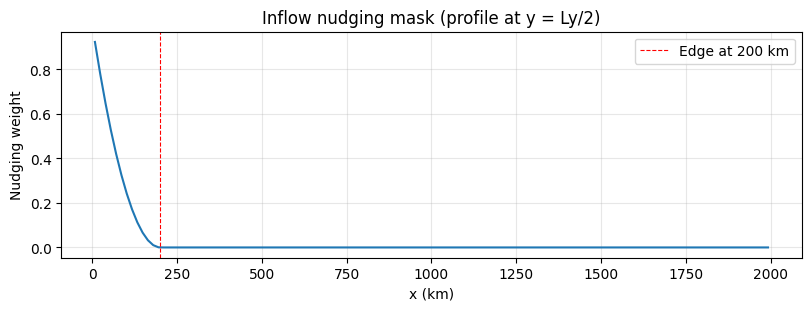

In [23]:
# Nudging mask: strong at left boundary, zero elsewhere
# Shape: maximum at x=0, decays as (1 - x/x_edge)² to zero at x = 10% of Lx
nudge_edge = 0.10 * Lx
nudge_mask = np.maximum(0.0, 1.0 - Xc / nudge_edge)**2    # (ny, nx)

nudge_tau  = 5 * dt    # nudging timescale (s)

print(f"Nudging active over leftmost {nudge_edge/1e3:.0f} km")
print(f"Nudging timescale: {nudge_tau:.0f} s")

# Visualise the nudging mask
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(xc/1e3, nudge_mask[ny//2, :])
ax.set_xlabel("x (km)"); ax.set_ylabel("Nudging weight")
ax.set_title("Inflow nudging mask (profile at y = Ly/2)")
ax.axvline(nudge_edge/1e3, color='r', ls='--', lw=0.8, label=f'Edge at {nudge_edge/1e3:.0f} km')
ax.legend(); ax.grid(alpha=0.3)
plt.show()


## 6. The integrator

In [24]:
def continuity(u, v, H0, dx, dy):
    """η tendency from wind divergence."""
    return -H0 * ((u[:,1:] - u[:,:-1])/dx + (v[1:,:] - v[:-1,:])/dy)


def pressure_grad(eta, hb, g, dx, dy):
    """Pressure gradient of surface height (η + hb) at staggered face points."""
    surf = eta + hb
    return (g*(surf[:,1:] - surf[:,:-1])/dx,    # (ny, nx-1) at u-faces
            g*(surf[1:,:] - surf[:-1,:])/dy)    # (ny-1, nx) at v-faces


def coriolis_at_u(v, f):
    return  f * 0.25*(v[:-1,:-1] + v[:-1,1:] + v[1:,:-1] + v[1:,1:])


def coriolis_at_v(u, f):
    return -f * 0.25*(u[:-1,:-1] + u[:-1,1:] + u[1:,:-1] + u[1:,1:])


def step(eta, u, v, hb, g, H0, f, nu, dx, dy, dt,
         eta_geo, nudge_mask, nudge_tau, U_bg):
    """
    Forward-backward step with steady inflow nudging.

    The nudge term restores η toward its geostrophically balanced value
    in the left boundary region, maintaining a steady inflow throughout
    the simulation and producing a clean quasi-steady lee wave pattern.
    """
    # Nudge η toward geostrophic background in inflow region
    nudge = -(eta - eta_geo) * nudge_mask / nudge_tau

    # --- Step 1: update η (with nudging) ---
    eta_new = eta + dt * (continuity(u, v, H0, dx, dy) + nudge)

    # --- Step 2: update winds using eta_new ---
    dPdx, dPdy = pressure_grad(eta_new, hb, g, dx, dy)

    u_new = u.copy()
    u_new[:,1:-1] = u[:,1:-1] + dt*(-dPdx + coriolis_at_u(v,f) - nu*u[:,1:-1])
    # Left boundary: nudge u toward U_bg (inflow)
    u_new[:,0]  = U_bg * (1 - np.exp(-dt / nudge_tau))
    # Right boundary: zero-gradient outflow
    u_new[:,-1] = u_new[:,-2]

    v_new = v.copy()
    v_new[1:-1,:] = v[1:-1,:] + dt*(-dPdy + coriolis_at_v(u_new,f) - nu*v[1:-1,:])
    v_new[0,:]  = 0.0
    v_new[-1,:] = 0.0

    return eta_new, u_new, v_new


def to_centres(u, v):
    return 0.5*(u[:,:-1]+u[:,1:]), 0.5*(v[:-1,:]+v[1:,:])


## 7. Run the integration

In [25]:
# Initialise from rest
eta = np.zeros((ny, nx))
u   = np.zeros((ny,   nx+1))
v   = np.zeros((ny+1, nx  ))

snap_eta = []; snap_u = []; snap_v = []; times = []

for n in range(n_steps):
    eta, u, v = step(eta, u, v, hb, g, H0, f, nu, dx, dy, dt,
                     eta_geo, nudge_mask, nudge_tau, U_bg)
    if (n+1) % save_every == 0:
        uc, vc = to_centres(u, v)
        snap_eta.append(eta.copy())
        snap_u.append(uc.copy())
        snap_v.append(vc.copy())
        times.append((n+1)*dt)

print(f"Integration complete: {n_steps} steps, {times[-1]/3600:.1f} hours simulated.")
print(f"Saved {len(snap_eta)} snapshots.")
print(f"Max surface anomaly: {max(np.abs(s).max() for s in snap_eta):.1f} m")


Integration complete: 7200 steps, 100.0 hours simulated.
Saved 180 snapshots.
Max surface anomaly: 717.4 m


## 8. Visualisation

### 8a. Quasi-steady state snapshot

The simulation is run long enough for the wave pattern to reach a near-steady state.
We plot the final snapshot with streamlines to show the full flow structure.


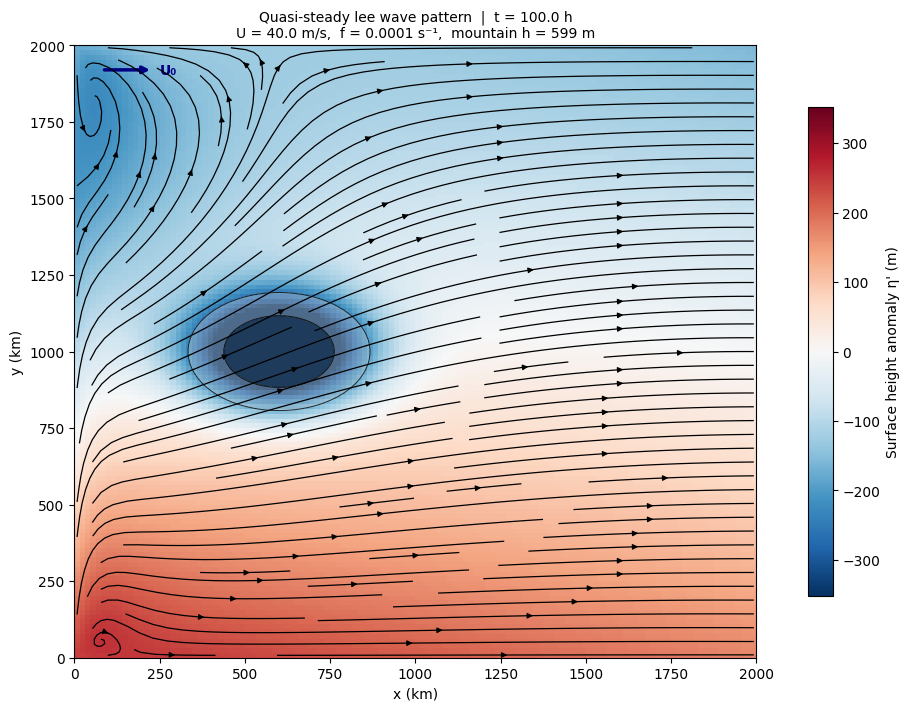

Saved: shallow_water_snapshot_steady.png


In [26]:
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

vmax = np.percentile(np.abs(snap_eta[-1]), 98)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im   = ax.pcolormesh(Xc/1e3, Yc/1e3, snap_eta[-1],
                     cmap='RdBu_r', norm=norm, shading='auto')
ax.contourf(Xc/1e3, Yc/1e3, hb, levels=[200,400,600],
            cmap='Greys', alpha=0.35, zorder=2)
ax.contour(Xc/1e3, Yc/1e3, hb, levels=[200,400,600],
           colors='k', linewidths=0.7, alpha=0.8, zorder=3)
ax.streamplot(Xc[0,:]/1e3, Yc[:,0]/1e3,
              snap_u[-1], snap_v[-1],
              density=1.5, linewidth=0.9, color='k',
              arrowsize=0.8, zorder=4)
plt.colorbar(im, ax=ax, label="Surface height anomaly η' (m)", shrink=0.8)
ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
ax.set_title(f"Quasi-steady lee wave pattern  |  t = {times[-1]/3600:.1f} h\n"
             f"U = {U_bg} m/s,  f = {f} s⁻¹,  mountain h = {hb.max():.0f} m",
             fontsize=10)
# Wind direction arrow
ax.annotate("", xy=(230, 1920), xytext=(80, 1920),
            arrowprops=dict(arrowstyle="->", color='navy', lw=2.5))
ax.text(250, 1920, "U₀", color='navy', fontsize=10, va='center', fontweight='bold')
plt.savefig("shallow_water_snapshot_steady.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shallow_water_snapshot_steady.png")


### 8b. Animation — wave pattern developing over time

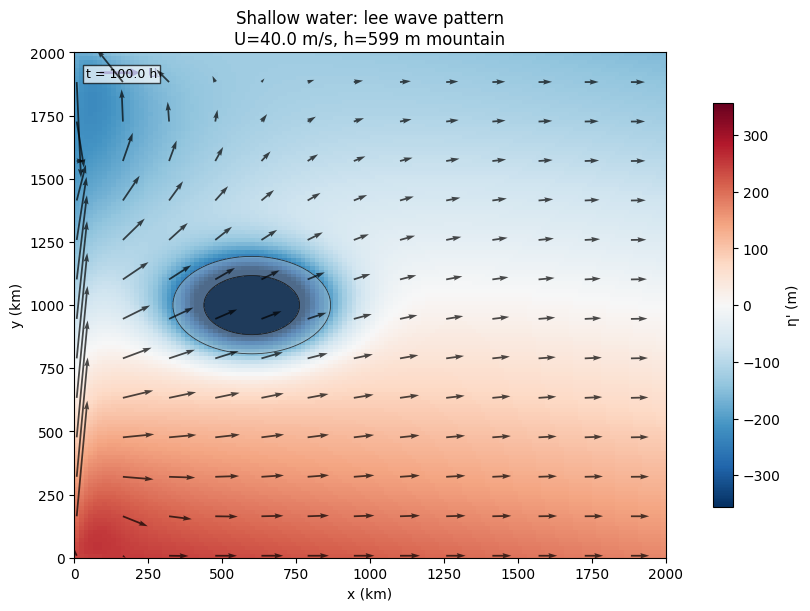

Saved: shallow_water_animation.gif


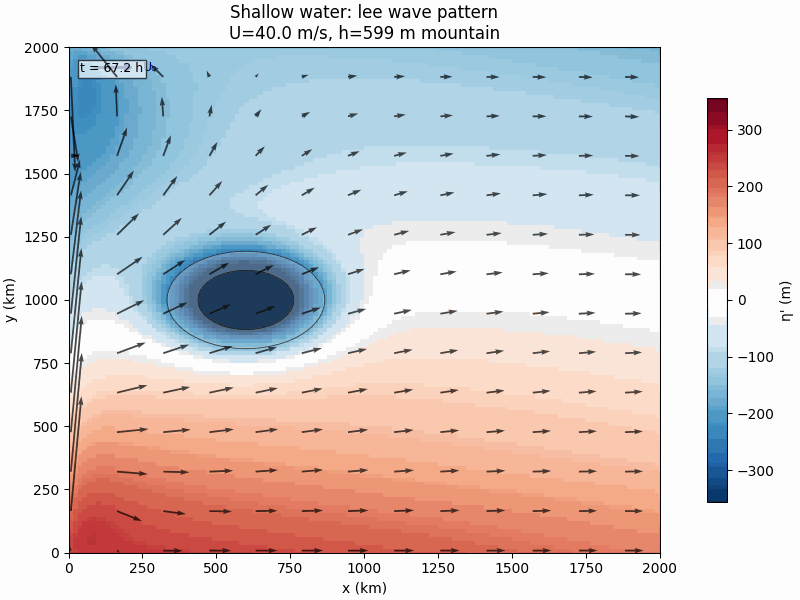

In [27]:
# Use the last 60 frames to show the quasi-steady pattern
n_anim   = min(60, len(snap_eta))
frames   = snap_eta[-n_anim:]
frames_u = snap_u[-n_anim:]
frames_v = snap_v[-n_anim:]
frame_t  = times[-n_anim:]

# Fixed colour scale across all animation frames
vmax_g = max(np.percentile(np.abs(s), 98) for s in frames)
vmax_g = max(vmax_g, 1.0)

fig_anim, ax_anim = plt.subplots(figsize=(8, 6), constrained_layout=True)
norm_a = TwoSlopeNorm(vmin=-vmax_g, vcenter=0, vmax=vmax_g)
im_a = ax_anim.pcolormesh(Xc/1e3, Yc/1e3, frames[0],
                           cmap='RdBu_r', norm=norm_a, shading='auto')
ax_anim.contourf(Xc/1e3, Yc/1e3, hb, levels=[200,400,600],
                  cmap='Greys', alpha=0.35, zorder=2)
ax_anim.contour(Xc/1e3, Yc/1e3, hb, levels=[200,400,600],
                 colors='k', linewidths=0.6, alpha=0.7, zorder=3)
s = 10
Q = ax_anim.quiver(Xc[::s,::s]/1e3, Yc[::s,::s]/1e3,
                    frames_u[0][::s,::s], frames_v[0][::s,::s],
                    scale=600, width=0.003, alpha=0.7, color='k', zorder=4)
plt.colorbar(im_a, ax=ax_anim, label="η' (m)", shrink=0.8)
ax_anim.set_xlabel("x (km)"); ax_anim.set_ylabel("y (km)")
ax_anim.set_title(f"Shallow water: lee wave pattern\nU={U_bg} m/s, h={hb.max():.0f} m mountain")
ax_anim.annotate("", xy=(230,1920), xytext=(80,1920),
                  arrowprops=dict(arrowstyle="->", color='navy', lw=2))
ax_anim.text(250, 1920, "U₀", color='navy', fontsize=9, va='center')
title_a = ax_anim.text(0.02, 0.97, "", transform=ax_anim.transAxes,
                        va='top', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.7, pad=2))

def update(frame):
    im_a.set_array(frames[frame].ravel())
    Q.set_UVC(frames_u[frame][::s,::s], frames_v[frame][::s,::s])
    title_a.set_text(f"t = {frame_t[frame]/3600:.1f} h")
    return im_a, Q, title_a

ani = animation.FuncAnimation(fig_anim, update, frames=len(frames),
                               interval=80, blit=True)
ani.save("shallow_water_animation.gif", writer='pillow', fps=12)
plt.show()
print("Saved: shallow_water_animation.gif")
Image("shallow_water_animation.gif")


## 9. Suggested experiments

**1. Wind speed**
- Increase `U_bg` from 20 to 40 m/s. Does the wave pattern strengthen or weaken?
- Set `U_bg = 5` m/s. What happens to the Rossby radius and the deflection angle?

**2. Coriolis**
- Set `f = 0`. The flow becomes symmetric — deflection is equal north and south of the mountain.
- Re-enable `f = 1e-4`. Which side of the mountain does the Coriolis force deflect flow toward?

**3. Mountain geometry**
- Switch to the N-S ridge (Option B in section 4). How does the wave pattern differ from an isolated peak?
- Try two mountains (Option C). Do the wave patterns interact?

**4. Mountain height**
- Increase `mountain_h` to 900 m. The linearisation assumes h << H0 — does the pattern look unphysical?

**5. Drag coefficient**
- Set `nu = 0`. What accumulates without damping?
- Set `nu = 1e-4`. How quickly does the wave pattern decay?

**6. Connect to the advection-diffusion model**
- In the advection-diffusion model, a tracer is carried passively by the wind.
  Use the wind field from the final snapshot (`snap_u[-1]`, `snap_v[-1]`) as the
  velocity field in the advection-diffusion code. Where would a pollutant released
  at the mountain end up?
